# Preliminary Tests

This first code will run a 'grid search' on the tiny sample of 79 MOA-printed chemicals as matched from the list of 100 that Grace gave me. It will not be a true grid search, as we won't use any cross-validation due to tiny sample size, but I will iterate through various parameters. 

In [102]:
#Read in the ld50 data
import pandas as pd

data = pd.read_csv('../src/data/moa_sample_pre-grid-search.csv').set_index('Unnamed: 0', drop = True)
data.head()

,LD50_LM,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,sc_Triazolinones,sc_Triazolocarboxamide,sc_Triazolopyrimidine_-_Type_1,sc_Triazolopyrimidine_-_Type_2,sc_Trifluoromethanesulfonanilides,sc_Triketones,sc_Triketones_(procide),sc_Uracils,sc_Ureas,sc_alpha-Chloroacetamides
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DTXSID6024177,1.183447,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID7022253,-0.565330,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID7034961,-0.052205,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
DTXSID4032619,-0.935266,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID7021948,0.707871,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
#Generate the parameter list for hybrid weights
from numpy import arange
fp_list = ["A", "B", "C", "D", "E"]
increment = 10
weight_list = list(arange(0,100+increment, increment))
params = []
for a in weight_list:
    for b in weight_list:
        if a + b > 100:
            password
        elif a + b == 100:
            params.append([a,b,0,0,0])
        else:
            for c in weight_list:
                if a+b+c > 100:
                    password
                elif a+b+c == 1000:
                    params.append([a,b,c,0,0])
                else:
                    for d in weight_list:
                        if a+b+c+d > 100:
                            password
                        elif a+b+c+d == 100:
                            params.append([a,b,c,d,0])
                        else:
                            for e in weight_list:
                                if a+b+c+d+e == 100:
                                    params.append([a,b,c,d,e])
                                else:
                                    password
print(len(params))

1001


In [104]:
from sklearn.model_selection import ParameterGrid

#Parameters for Grid Search
hybrid_weights = params
neighborhood_size = list(range(4,14))

params = {'hybrid_weights':hybrid_weights, 'n_neighbors': neighborhood_size}

#Parameters for set-up and record-keeping
slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, 5727), slice(5727, None)]

In [ ]:
#Search through all the possible print, neighborhood combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from genra.rax.skl.hybrid import GenRAPredValueHybrid
import numpy as np
from numpy import sqrt

params_list = ParameterGrid(params)
tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices)



results = {'print':[], 'n_neighbors':[], 'rmse':[], 'r2':[], 'nulls':[]}
for i in list(params_list):

    results['n_neighbors'].append(i['n_neighbors'])
    results['print'].append(i['hybrid_weights'])

    for key, value in i.items():
        setattr(tester, key, value)


    x_test = data.iloc[:,1:]
    y_test = data.iloc[:,0]

    y_preds = []

    for x, prints in x_test.iterrows():
        tester.fit(data.loc[data.index != x].iloc[:, 1:], data.loc[data.index != x].iloc[:,0])
        y_preds.append(tester.predict(prints.to_numpy().reshape(1,-1)))
    scorable_preds = []
    scorable_tests = []
    null_counter = 0
    for i in range(len(y_preds)):
        if np.isnan(y_preds[i]):
            null_counter += 1
            print(i)
        else:
            scorable_preds.append(y_preds[i])
            scorable_tests.append(y_test[i])
    r2 = r2_score(scorable_tests, scorable_preds)
    rmse = float(sqrt((sum([(scorable_preds[i]-scorable_tests[i])**2 for i in range(0,len(scorable_preds))])/len(scorable_preds))))
    results['r2'].append(r2)
    results['rmse'].append(rmse)
    results['nulls'].append(null_counter)

results_df = pd.DataFrame(results)
results_df.to_csv(f'../references/moa/sample_tests.csv')

In [ ]:
#Read in the results from the previous test if kernel has restarted since
import pandas as pd
results_df = pd.read_csv(f'../references/moa/sample_tests.csv').set_index("Unnamed: 0")

In [ ]:
#View the best results from the test
results_df.sort_values('r2', ascending=False).head(15)

,print,n_neighbors,rmse,r2,nulls
Unnamed: 0,,,,,
662,"[0, 10, 0, 0, 90]",6,0.779278,0.389899,0
2823,"[0, 90, 0, 0, 10]",7,0.780396,0.388147,0
5022,"[10, 80, 0, 0, 10]",6,0.782753,0.384446,0
5023,"[10, 80, 0, 0, 10]",7,0.783441,0.383364,0
1212,"[0, 20, 0, 0, 80]",6,0.783538,0.383212,0
2853,"[0, 100, 0, 0, 0]",7,0.784306,0.382002,0
2793,"[0, 80, 10, 0, 10]",7,0.784687,0.381401,0
663,"[0, 10, 0, 0, 90]",7,0.786025,0.379290,0
6673,"[20, 70, 0, 0, 10]",7,0.786175,0.379053,0


# One-Hot Encoding MOA data

In [162]:
import pandas as pd
frac_chems = pd.read_csv('../src/data/pesticide_classifications_frac.csv')
hrac_chems = pd.read_csv('../src/data/pesticide_classifications_hrac.csv')
irac_chems = pd.read_csv('../src/data/pesticide_classifications_irac.csv')

In [163]:
def removeColumns(df):
    df = df[['name', 'DSSTox_Substance_Id', 'structure_class', 'moa_class', 'pesticide_class', ]]
    return df
frac_chems = removeColumns(frac_chems)
hrac_chems = removeColumns(hrac_chems)
irac_chems = removeColumns(irac_chems)

In [164]:
master_moa_chems = pd.concat([frac_chems, hrac_chems, irac_chems])
master_moa_chems = master_moa_chems.rename(columns = {'DSSTox_Substance_Id':'dsstox_sid'})
master_moa_chems = master_moa_chems.set_index('dsstox_sid')

In [165]:
#Import information for creating structural fingerprints. These will be the columns
#beginning with cl (class), sup (superclass), sp (alternative parent), 
# dp (direct parent), and sub (substituent)
import requests


class_list = []
superclass_list = []
direct_parent_list = []
alt_parent_list = []
substituent_list = []
master_parent_list = []
master_substituent_list = []

for chem in master_moa_chems.index:
    url = f"https://hazard-dev.sciencedataexperts.com/api/resolver/classyfire?query={chem}"
    response = requests.get(url)
    response_json = response.json()
    if len(response_json['content'])>0:
        class_list.append(response_json['content'][0]['klass'])
        superclass_list.append(response_json['content'][0]['superklass'])
        direct_parent_list.append(response_json['content'][0]['directParent'])
        alt_parents = response_json['content'][0]['alternativeParents']
        alt_parents_text = ''
        
        for parent in alt_parents:
            master_parent_list.append(parent)
            alt_parents_text = alt_parents_text + parent + '$'
            alt_parents_text = alt_parents_text.replace(' ', '_')
        alt_parent_list.append(alt_parents_text)

        substituents = response_json['content'][0]['substituents']
        sub_text = ''
        for sub in substituents:
            master_substituent_list.append(sub)
            sub_text = sub_text + sub + '$'
            sub_text = sub_text.replace(' ', '_')
        substituent_list.append(sub_text)

        
    else:
        class_list.append('unknown')
        superclass_list.append('unknown')
        direct_parent_list.append('unknown')
        substituent_list.append('unknown')
        alt_parent_list.append('unknown')

In [166]:
master_moa_chems['class'] = class_list
master_moa_chems['superclass'] = superclass_list
master_moa_chems['parent'] = direct_parent_list
master_moa_chems['step_parents'] = alt_parent_list
master_moa_chems['substituents'] = substituent_list

master_moa_chems.to_csv('../references/class_tests/moa_and_classyfire.csv')
master_moa_chems

,name,structure_class,moa_class,pesticide_class,class,superclass,parent,step_parents,substituents
dsstox_sid,,,,,,,,,
DTXSID1032519,acibenzolar-S-methyl,NaN,Host Plant Defence Induction,fungicide,Benzothiadiazoles,Organoheterocyclic compounds,Benzothiadiazoles,Azacyclic_compounds$Benzenoids$Carbothioic_S-e...,Thiocarboxylic_acid_or_derivatives$Sulfenyl_co...
DTXSID1058216,aldimorph,NaN,Sterol Biosynthesis in Membranes,fungicide,unknown,unknown,unknown,unknown,unknown
DTXSID2058203,ametoctradin,NaN,Respiration,fungicide,Triazolopyrimidines,Organoheterocyclic compounds,Triazolopyrimidines,Azacyclic_compounds$Heteroaromatic_compounds$H...,"Triazole$1,2,4-triazole$Azacycle$Heteroaromati..."
DTXSID0058063,amisulbrom,NaN,Respiration,fungicide,Indoles and derivatives,Organoheterocyclic compounds,Indoles,Aryl_bromides$Aryl_fluorides$Azacyclic_compoun...,Aryl_fluoride$Organosulfonic_acid_or_derivativ...
DTXSID9020089,anilazine,NaN,Chemicals with Multi-Site Activity,fungicide,Triazines,Organoheterocyclic compounds,Aminotriazines,Aryl_chlorides$Azacyclic_compounds$Chloro-s-tr...,"Monocyclic_benzene_moiety$Amino-1,3,5-triazine..."
...,...,...,...,...,...,...,...,...,...
DTXSID4020450,Dicofol,Dicofol,Uncertain MOA,Insecticide,Benzene and substituted derivatives,Benzenoids,Diphenylmethanes,Alkyl_chlorides$Aromatic_alcohols$Aryl_chlorid...,Aromatic_alcohol$Aryl_chloride$Chlorobenzene$A...
DTXSID7034414,Lime Sulfur,Lime Sulfur,Uncertain MOA,Insecticide,unknown,unknown,unknown,unknown,unknown
DTXSID0034695,Mancozeb,Mancozeb,Uncertain MOA,Insecticide,unknown,unknown,unknown,unknown,unknown


In [253]:
#Retrieve if you need to undo subsequent changes
master_moa_chems = pd.read_csv('../references/class_tests/moa_and_classyfire.csv').set_index('dsstox_sid', drop = True)

In [254]:
#Create all step_parent print columns and temporarily fill with zeros
master_parent_set = set()
for item in set(master_parent_list):
    item = item.replace(' ', '_')
    item = f'sp_{item}'
    master_parent_set.add(item) 
    master_moa_chems = master_moa_chems.copy()
    master_moa_chems[item] = 0
master_moa_chems


,name,structure_class,moa_class,pesticide_class,class,superclass,parent,step_parents,substituents,sp_4-halobenzoic_acids,...,sp_Organoiodides,sp_Thiocarbonyl_compounds,sp_Cyclopropanecarboxylic_acids_and_derivatives,sp_Phenylpiperidines,sp_Aniline_and_substituted_anilines,"sp_1,3-dithioles",sp_Thiohemiaminal_derivatives,sp_Alkylsilanes,sp_Organic_sulfonamides,sp_Organic_alkali_metal_salts
dsstox_sid,,,,,,,,,,,,,,,,,,,,,
DTXSID1032519,acibenzolar-S-methyl,NaN,Host Plant Defence Induction,fungicide,Benzothiadiazoles,Organoheterocyclic compounds,Benzothiadiazoles,Azacyclic_compounds$Benzenoids$Carbothioic_S-e...,Thiocarboxylic_acid_or_derivatives$Sulfenyl_co...,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID1058216,aldimorph,NaN,Sterol Biosynthesis in Membranes,fungicide,unknown,unknown,unknown,unknown,unknown,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID2058203,ametoctradin,NaN,Respiration,fungicide,Triazolopyrimidines,Organoheterocyclic compounds,Triazolopyrimidines,Azacyclic_compounds$Heteroaromatic_compounds$H...,"Triazole$1,2,4-triazole$Azacycle$Heteroaromati...",0,...,0,0,0,0,0,0,0,0,0,0
DTXSID0058063,amisulbrom,NaN,Respiration,fungicide,Indoles and derivatives,Organoheterocyclic compounds,Indoles,Aryl_bromides$Aryl_fluorides$Azacyclic_compoun...,Aryl_fluoride$Organosulfonic_acid_or_derivativ...,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID9020089,anilazine,NaN,Chemicals with Multi-Site Activity,fungicide,Triazines,Organoheterocyclic compounds,Aminotriazines,Aryl_chlorides$Azacyclic_compounds$Chloro-s-tr...,"Monocyclic_benzene_moiety$Amino-1,3,5-triazine...",0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DTXSID4020450,Dicofol,Dicofol,Uncertain MOA,Insecticide,Benzene and substituted derivatives,Benzenoids,Diphenylmethanes,Alkyl_chlorides$Aromatic_alcohols$Aryl_chlorid...,Aromatic_alcohol$Aryl_chloride$Chlorobenzene$A...,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID7034414,Lime Sulfur,Lime Sulfur,Uncertain MOA,Insecticide,unknown,unknown,unknown,unknown,unknown,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID0034695,Mancozeb,Mancozeb,Uncertain MOA,Insecticide,unknown,unknown,unknown,unknown,unknown,0,...,0,0,0,0,0,0,0,0,0,0


In [255]:
#Create all substituent columns and temporarily fill all with zeros
master_substituent_set = set()
for item in set(master_substituent_list):
    item = item.replace(' ', '_')
    item = f'sub_{item}'
    master_substituent_set.add(item) 
    master_moa_chems = master_moa_chems.copy()
    master_moa_chems[item] = 0
master_moa_chems


,name,structure_class,moa_class,pesticide_class,class,superclass,parent,step_parents,substituents,sp_4-halobenzoic_acids,...,sub_N-alkylpyrrolidine,sub_Delta-Lactam,sub_Naphthalene,sub_Toluamide,sub_O-sulfanylbenzoic_acid_or_derivatives,sub_Pyrazinecarboxamide,sub_S-triazinyl-2-sulfonylurea,sub_Alpha-chloroketone,sub_Isoxazoline,"sub_2,5-disubstituted_1,3-thiazole"
dsstox_sid,,,,,,,,,,,,,,,,,,,,,
DTXSID1032519,acibenzolar-S-methyl,NaN,Host Plant Defence Induction,fungicide,Benzothiadiazoles,Organoheterocyclic compounds,Benzothiadiazoles,Azacyclic_compounds$Benzenoids$Carbothioic_S-e...,Thiocarboxylic_acid_or_derivatives$Sulfenyl_co...,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID1058216,aldimorph,NaN,Sterol Biosynthesis in Membranes,fungicide,unknown,unknown,unknown,unknown,unknown,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID2058203,ametoctradin,NaN,Respiration,fungicide,Triazolopyrimidines,Organoheterocyclic compounds,Triazolopyrimidines,Azacyclic_compounds$Heteroaromatic_compounds$H...,"Triazole$1,2,4-triazole$Azacycle$Heteroaromati...",0,...,0,0,0,0,0,0,0,0,0,0
DTXSID0058063,amisulbrom,NaN,Respiration,fungicide,Indoles and derivatives,Organoheterocyclic compounds,Indoles,Aryl_bromides$Aryl_fluorides$Azacyclic_compoun...,Aryl_fluoride$Organosulfonic_acid_or_derivativ...,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID9020089,anilazine,NaN,Chemicals with Multi-Site Activity,fungicide,Triazines,Organoheterocyclic compounds,Aminotriazines,Aryl_chlorides$Azacyclic_compounds$Chloro-s-tr...,"Monocyclic_benzene_moiety$Amino-1,3,5-triazine...",0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DTXSID4020450,Dicofol,Dicofol,Uncertain MOA,Insecticide,Benzene and substituted derivatives,Benzenoids,Diphenylmethanes,Alkyl_chlorides$Aromatic_alcohols$Aryl_chlorid...,Aromatic_alcohol$Aryl_chloride$Chlorobenzene$A...,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID7034414,Lime Sulfur,Lime Sulfur,Uncertain MOA,Insecticide,unknown,unknown,unknown,unknown,unknown,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID0034695,Mancozeb,Mancozeb,Uncertain MOA,Insecticide,unknown,unknown,unknown,unknown,unknown,0,...,0,0,0,0,0,0,0,0,0,0


In [256]:
#Fill 1s in where they belong by iterating through rows and filling their step-parent
#and substituent cells in
master_moa_chems = master_moa_chems.fillna('')
for chem_id, info in master_moa_chems.iterrows():
    substituents = info['substituents']
    parents = info['step_parents']
    master_moa_chems = master_moa_chems.copy()
    for sub in substituents.split('$')[:-1]:
        master_moa_chems.loc[chem_id, f'sub_{sub}'] = 1
    for step in parents.split('$')[:-1]:
        master_moa_chems.loc[chem_id, f'sp_{step}'] = 1


In [257]:
#Drop out the columns we just one-hot encoded manually
master_moa_chems = master_moa_chems.drop(columns = ['substituents', 'step_parents'])

In [258]:
#One-Hot Encode the columns that can be easily processed by sklearn
from sklearn.preprocessing import OneHotEncoder

#Set up the data frame and replace the blank structure classes with 'unknown' for clearer future labelling
moa_frame = master_moa_chems.copy()
moa_frame = moa_frame.replace('','unknown')
coded_columns = [ 'class', 'superclass', 'parent','structure_class', 'moa_class', 'pesticide_class']

#Use a function to quickly create column names to feed the encoded frame
name_list = []
def makeColumns(column_name, prefix):
    names = moa_frame[column_name].unique()
    for name in names:
        name_list.append(prefix + '_' + name.replace(' ', '_'))
    return

#Apply the function to each column
makeColumns('class', 'cl')
makeColumns('superclass', 'sup')
makeColumns('parent', 'dp')
makeColumns('structure_class', 'sc')
makeColumns('moa_class', 'mc')
makeColumns('pesticide_class', 'pc')


#One-hot encode the data and tag on the column names we made
encoder = OneHotEncoder(sparse_output = False)
coded_values = encoder.fit_transform(moa_frame[coded_columns])

pd.DataFrame(coded_values)
coded_df = pd.DataFrame(coded_values, columns = name_list, index = moa_frame.index)

coded_df.head()


,cl_Benzothiadiazoles,cl_unknown,cl_Triazolopyrimidines,cl_Indoles_and_derivatives,cl_Triazines,cl_Benzene_and_substituted_derivatives,cl_Organooxygen_compounds,cl_Carboxylic_acids_and_derivatives,cl_Benzimidazoles,cl_Tetralins,...,mc_Mitochondrial_complex_IV_electron_transport_inhibitor,mc_Mitochondrial_complex_II_electron_transport_inhibitor,mc_Ryanodine_receptor_modulator,mc_Chorodoonal_organ_modulator,mc_GABA-gated_chloride_channel_allosteric_modulator,mc_KCA2_modulator,mc_Uncertain_MOA,pc_fungicide,pc_Herbicide,pc_Insecticide
dsstox_sid,,,,,,,,,,,,,,,,,,,,,
DTXSID1032519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID1058216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID2058203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID0058063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID9020089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [259]:
#Drop all of the non-print columns and combine the two frames
coded_columns.append('name')
master_moa_chems = pd.concat([master_moa_chems, coded_df], axis = 1).drop(columns = coded_columns)

In [260]:
#View the results
master_moa_chems.head()

,sp_4-halobenzoic_acids,sp_Chlorohydrins,sp_Organic_antimony_salts,sp_Fatty_acid_esters,sp_1-hydroxy-4-unsubstituted_benzenoids,sp_Vinyl_chlorides,sp_o-Xylenes,sp_Furan-3-carboxylic_acid_and_derivatives,sp_Carboximidic_acids,sp_Lactams,...,mc_Mitochondrial_complex_IV_electron_transport_inhibitor,mc_Mitochondrial_complex_II_electron_transport_inhibitor,mc_Ryanodine_receptor_modulator,mc_Chorodoonal_organ_modulator,mc_GABA-gated_chloride_channel_allosteric_modulator,mc_KCA2_modulator,mc_Uncertain_MOA,pc_fungicide,pc_Herbicide,pc_Insecticide
dsstox_sid,,,,,,,,,,,,,,,,,,,,,
DTXSID1032519,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID1058216,0,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID2058203,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID0058063,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID9020089,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [261]:
#Save to CSV for use with other prints
master_moa_chems.to_csv('../references/class_tests/moa_and_classyfire_coded.csv')

In [270]:
#Retrieve the column number for the first MOA print column
counter = 0
for name in master_moa_chems.columns:
    if 'sc_' in name:
        print(counter)
        break
    else:
        counter += 1



1439


# MOA Tests with OHE Data

In [272]:
#Read in the LD50 data
ld50 = pd.read_csv('../src/data/LD50_pre-grid-search.csv').set_index('Unnamed: 0')

In [273]:
#Combine the two data frames. Note that len(ld50_with_moa) = 458, so we lose 
# many of our moa chemicals here *but likely have more than for any individual 
# toxref endpoint
ld50_with_moa = ld50.join(master_moa_chems, how = 'inner')
ld50_with_moa.head()

,LD50_LM,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,mc_Mitochondrial_complex_IV_electron_transport_inhibitor,mc_Mitochondrial_complex_II_electron_transport_inhibitor,mc_Ryanodine_receptor_modulator,mc_Chorodoonal_organ_modulator,mc_GABA-gated_chloride_channel_allosteric_modulator,mc_KCA2_modulator,mc_Uncertain_MOA,pc_fungicide,pc_Herbicide,pc_Insecticide
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DTXSID3032622,-1.497014,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID9020089,-0.991211,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
DTXSID7020764,-0.749458,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
DTXSID3041617,-0.310023,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
DTXSID7037551,-1.590786,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [295]:
#Send across to VM
print(f"scp src/data/ld50_with_moa_pre-grid-search.csv aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/data")

scp src/data/ld50_with_moa_pre-grid-search.csv aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/data


In [353]:
#Generate the parameter list for hybrid weights
from numpy import arange
fp_list = ["A", "B", "C", "D", "E", "F"]
increment = 2
weight_list = list(arange(0,100+increment, increment))
params = []
for a in arange(36,41,1):
    for b in arange(12,21,1):
        for c in arange(0,7,1):
            for d in arange(0,3,1):
                for e in arange(30,39,1):
                    for f in arange(10,11,1):
                        if a+b+c+d+e+f == 100:
                            params.append([a,b,c,d,e,f])
                        else:
                            password
print(len(params))

667


In [331]:
from sklearn.model_selection import ParameterGrid

#Parameters for Grid Search
hybrid_weights = params
neighborhood_size = list(range(8,9))

params = {'hybrid_weights':hybrid_weights, 'n_neighbors': neighborhood_size}

#Parameters for set-up and record-keeping
slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, 5727), slice(5727, 7166), slice(7166, None)]

In [332]:
import random
test_random = random.randint(0,10000)
test_random = 7582

In [333]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ld50_with_moa.iloc[:,1:], ld50_with_moa.iloc[:,0], random_state = test_random)

In [ ]:
#Search through all the possible print, neighborhood combinations over 5 states 
#for cross-validation
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from genra.rax.skl.hybrid import GenRAPredValueHybrid
from numpy import sqrt

params_list = ParameterGrid(params)
tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, metric = 'jaccard')

data = ld50_with_moa.copy()

results = {'print':[],'rmse':[], 'r2':[], 'state':[], 'nulls':[]}
for i in list(params_list):

    for _ in range(1):

        results['print'].append(i['hybrid_weights'])

    for key, value in i.items():
        setattr(tester, key, value)

    y_preds = []

    for x, prints in x_train.iterrows():
        tester.fit(data.loc[data.index != x].iloc[:, 1:], data.loc[data.index != x].iloc[:,0])
        y_preds.append(tester.predict(prints.to_numpy().reshape(1,-1)))
    scorable_preds = []
    scorable_tests = []
    null_counter = 0
    for i in range(len(y_preds)):
        if np.isnan(y_preds[i]):
            null_counter += 1
            
        else:
            scorable_preds.append(y_preds[i])
            scorable_tests.append(y_train[i])
    r2 = r2_score(scorable_tests, scorable_preds)
    rmse = float(sqrt((sum([(scorable_preds[i]-scorable_tests[i])**2 for i in range(0,len(scorable_preds))])/len(scorable_preds))))
    results['r2'].append(r2)
    results['rmse'].append(rmse)
    results['nulls'].append(null_counter)
    results['state'].append(state)
results_df = pd.DataFrame(results)
results_df.to_csv(f'../references/class_tests/moa_tests/ld50_grid_search_local.csv')

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.drop(columns = 'state')
results_df.to_csv(f'../references/class_tests/moa_tests/ld50_grid_search_granulation20.csv')

In [ ]:
results_df.sort_values('r2', ascending = False).head(10)

10-Fold CV used with increments 10 and 20, but reduced to 5-fold at increment 2 due to too many tests present. Back up to 10 at single-fold due to low test volume needed. 

In [355]:
from sklearn.model_selection import GridSearchCV

tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, metric = 'jaccard')
parameters = {'hybrid_weights': params}

search = GridSearchCV(estimator = tester, param_grid = parameters, cv = 10, verbose = 10, n_jobs = -1, scoring = ['r2', 'neg_root_mean_squared_error'], refit = 'neg_root_mean_squared_error' )
results = search.fit(x_train, y_train)
cv_df = pd.DataFrame(results.cv_results_)
cv_df.to_csv('../references/class_tests/moa_tests/ld50_grid_search_granulation2_cv10.csv')

Fitting 10 folds for each of 667 candidates, totalling 6670 fits


In [356]:
cv_df.sort_values('mean_test_neg_root_mean_squared_error', ascending = False)[['param_hybrid_weights', 'mean_test_neg_root_mean_squared_error']].head(10)

,param_hybrid_weights,mean_test_neg_root_mean_squared_error
136,"[36, 19, 4, 0, 31, 10]",-0.572392
562,"[40, 12, 0, 0, 38, 10]",-0.572563
146,"[36, 20, 2, 1, 31, 10]",-0.573717
517,"[39, 16, 0, 0, 35, 10]",-0.573849
241,"[37, 16, 5, 1, 31, 10]",-0.573914
148,"[36, 20, 3, 0, 31, 10]",-0.573926
134,"[36, 19, 3, 1, 31, 10]",-0.573951
121,"[36, 18, 5, 0, 31, 10]",-0.574069
621,"[40, 15, 0, 0, 35, 10]",-0.574109
260,"[37, 17, 5, 0, 31, 10]",-0.574198


In [362]:
for x, prints in data.iterrows():
    password
x, prints

('DTXSID3034458',
 LD50_LM             -0.577345
 tp_fp0               0.000000
 tp_fp1               0.000000
 tp_fp2               0.000000
 tp_fp3               0.000000
                        ...   
 mc_KCA2_modulator    0.000000
 mc_Uncertain_MOA     0.000000
 pc_fungicide         1.000000
 pc_Herbicide         0.000000
 pc_Insecticide       0.000000
 Name: DTXSID3034458, Length: 7375, dtype: float64)

In [365]:
prints

LD50_LM             -1.497014
tp_fp0               0.000000
tp_fp1               0.000000
tp_fp2               0.000000
tp_fp3               0.000000
                       ...   
mc_KCA2_modulator    0.000000
mc_Uncertain_MOA     0.000000
pc_fungicide         0.000000
pc_Herbicide         0.000000
pc_Insecticide       1.000000
Name: DTXSID3032622, Length: 7375, dtype: float64

In [382]:
tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, metric = 'jaccard', hybrid_weights = [36, 19, 4, 0, 31, 10])
data_predicted = data.copy()

y_preds = []
y_train = data.iloc[:,0]
for x, prints in data.iloc[:,1:].iterrows():
    tester.fit(data.loc[data.index != x].iloc[:, 1:], data.loc[data.index != x].iloc[:,0])
    y_preds.append(tester.predict(prints.to_numpy().reshape(1,-1))[0])
scorable_preds = []
scorable_tests = []
null_counter = 0
for i in range(len(y_preds)):
    if np.isnan(y_preds[i]):
        null_counter += 1
    else:
        scorable_preds.append(y_preds[i])
        scorable_tests.append(y_train[i])

data_predicted['grid_preds'] = y_preds

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [383]:
tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, metric = 'jaccard', hybrid_weights = [0, 100, 0, 0, 0, 0])


y_preds = []
for x, prints in data.iloc[:,1:].iterrows():
    tester.fit(data.loc[data.index != x].iloc[:, 1:], data.loc[data.index != x].iloc[:,0])
    y_preds.append(tester.predict(prints.to_numpy().reshape(1,-1))[0])
scorable_preds = []
scorable_tests = []
null_counter = 0
for i in range(len(y_preds)):
    if np.isnan(y_preds[i]):
        null_counter += 1
        
    else:
        scorable_preds.append(y_preds[i])
        scorable_tests.append(y_train[i])

data_predicted['mor_preds'] = y_preds

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [384]:
tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, metric = 'jaccard', hybrid_weights = [28, 56, 7, 9, 0, 0])


y_preds = []
for x, prints in data.iloc[:,1:].iterrows():
    tester.fit(data.loc[data.index != x].iloc[:, 1:], data.loc[data.index != x].iloc[:,0])
    y_preds.append(tester.predict(prints.to_numpy().reshape(1,-1))[0])
scorable_preds = []
scorable_tests = []
null_counter = 0
for i in range(len(y_preds)):
    if np.isnan(y_preds[i]):
        null_counter += 1
        
    else:
        scorable_preds.append(y_preds[i])
        scorable_tests.append(y_train[i])

data_predicted['opt_preds'] = y_preds

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [391]:
test_set = data_predicted.loc[list(x_test.index),:]
test_set


,LD50_LM,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,mc_GABA-gated_chloride_channel_allosteric_modulator,mc_KCA2_modulator,mc_Uncertain_MOA,pc_fungicide,pc_Herbicide,pc_Insecticide,grid_preds,mor_preds,opt_preds,opt0_preds
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DTXSID8024280,-0.641786,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,-0.551137,-0.487488,-0.529542,-0.526115
DTXSID7058179,-0.718035,0,0,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,-0.575701,-0.864069,-0.672384,-0.829089
DTXSID4034653,-0.843026,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,-0.558629,-0.580912,-0.563710,-0.566014
DTXSID9058315,0.039478,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,-0.701253,-0.850525,-0.760174,-0.755977
DTXSID7034753,-0.933383,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.936692,-0.811245,-0.842988,-0.842281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DTXSID3039240,0.763994,0,1,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,-0.750809,-0.753023,-0.638493,-0.640615
DTXSID2042359,-0.761667,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,-0.571990,-0.097577,-0.211979,-0.104432
DTXSID3041615,-1.203599,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.850596,-0.851716,-0.850003,-0.850232


In [401]:
from sklearn.metrics import root_mean_squared_error, r2_score
df = pd.DataFrame({'print':['morgan', 'moa_grid', 'optimal']})
df['r2'] = [r2_score(test_set['LD50_LM'], test_set['mor_preds']), r2_score(test_set['LD50_LM'], test_set['grid_preds']), r2_score(test_set['LD50_LM'], test_set['opt_preds'])]

In [403]:
df['rmse'] = [root_mean_squared_error(test_set['LD50_LM'], test_set['mor_preds']), root_mean_squared_error(test_set['LD50_LM'], test_set['grid_preds']), root_mean_squared_error(test_set['LD50_LM'], test_set['opt_preds'])]
df.sort_values('r2', ascending = False)

,print,r2,rmse
1,moa_grid,0.513881,0.608881
0,morgan,0.463924,0.639402
2,optimal,0.441243,0.652788


In [ ]:
tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, metric = 'jaccard', hybrid_weights = [22.59, 59.59, 11.08, 6.75, 0, 0])


y_preds = []
for x, prints in data.iloc[:,1:].iterrows():
    tester.fit(data.loc[data.index != x].iloc[:, 1:], data.loc[data.index != x].iloc[:,0])
    y_preds.append(tester.predict(prints.to_numpy().reshape(1,-1))[0])
scorable_preds = []
scorable_tests = []
null_counter = 0
for i in range(len(y_preds)):
    if np.isnan(y_preds[i]):
        null_counter += 1
        
    else:
        scorable_preds.append(y_preds[i])
        scorable_tests.append(y_train[i])

data_predicted['opt0_preds'] = y_preds

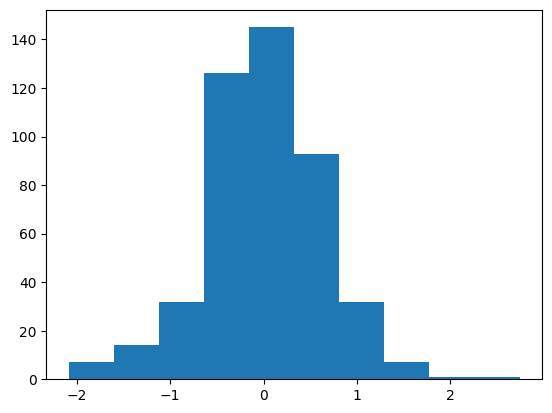

In [394]:
import matplotlib.pyplot as plt

plt.hist(data_predicted['mor_preds']-data_predicted['LD50_LM'])
plt.show()

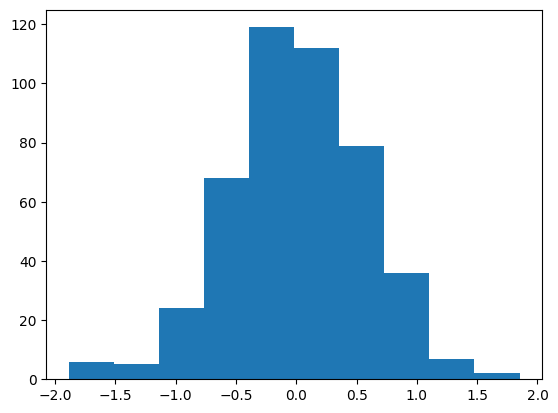

In [395]:
plt.hist(data_predicted['grid_preds']-data_predicted['LD50_LM'])
plt.show()

In [398]:
from numpy import mean

mean(abs(data_predicted['LD50_LM'] - data_predicted['mor_preds'])), mean(abs(data_predicted['LD50_LM'] - data_predicted['grid_preds']))

(0.48704620639002405, 0.45070977507212134)

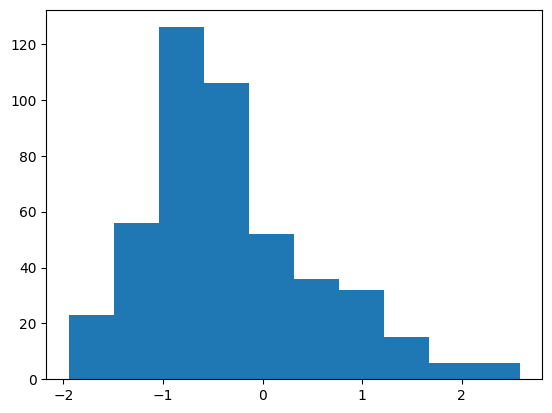

In [404]:
plt.hist(data_predicted["LD50_LM"])
plt.show()

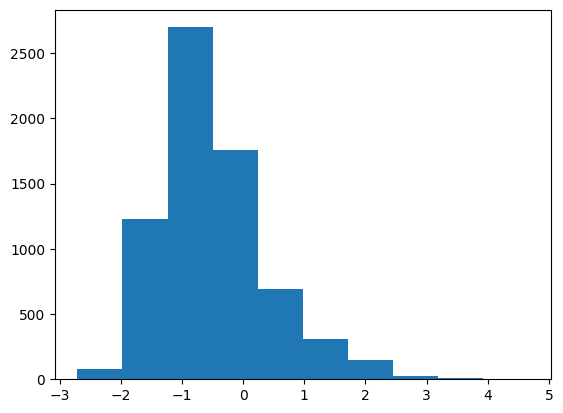

In [406]:
plt.hist(ld50['LD50_LM'])
plt.show()